# Illustrative Example 1: GP Differentiation — Duffing Oscillator

This notebook demonstrates **Gaussian Process (GP) differentiation** of a noisy time series using the Matérn 5/2 state-space model with a Kalman filter / Rauch–Tung–Striebel (RTS) smoother backend.

**Task**: given noisy observations of the displacement $x(t)$, simultaneously estimate the velocity $\dot{x}(t)$ and acceleration $\ddot{x}(t)$.

Reproduces Figure 3 from:
> *Differentiation and Integration of Time Series via Gaussian Process Regression for Structural Health Monitoring Applications*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from data_generation import generate_data_Duffing_oscillator, add_measurement_noise
from gp_optimization import optimize_hyperparams_Matern52_and_measurement_noise
import KalmanFilter_functions as KF
from plotting_functions import plot_states_with_zoom

## 1. Data Generation

We simulate the Duffing oscillator and add Gaussian measurement noise to the displacement signal.

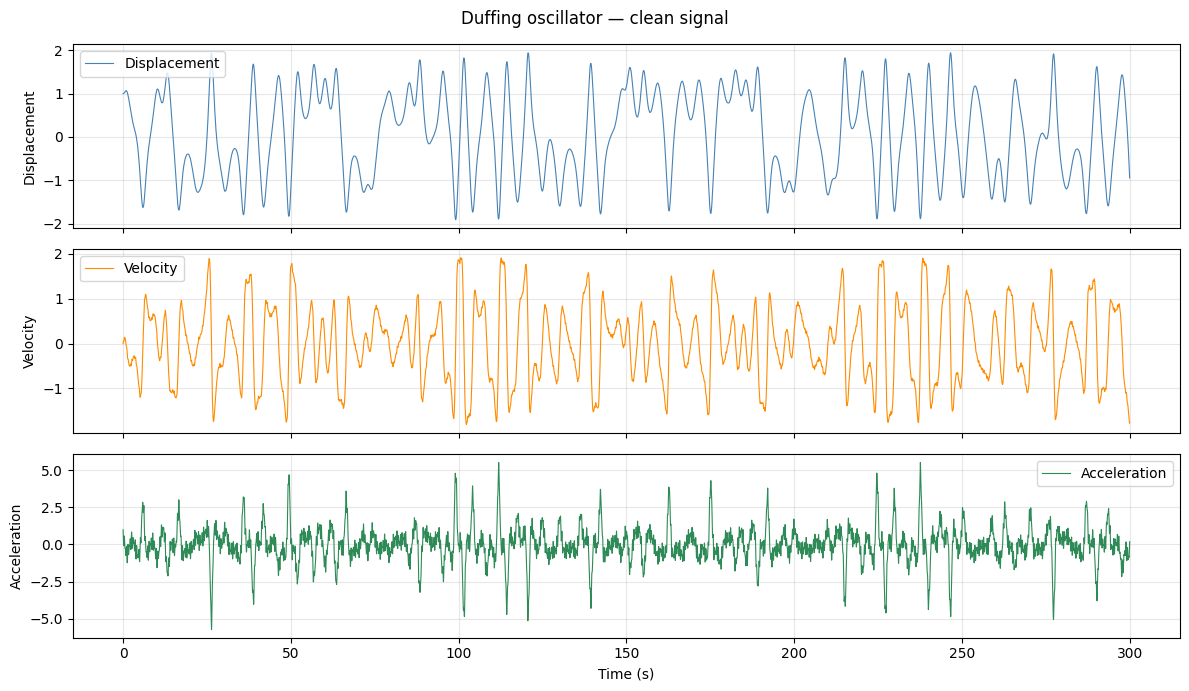

In [2]:
# Simulate Duffing oscillator
t, states, derivatives = generate_data_Duffing_oscillator()
dt = t[1] - t[0]
n_steps = len(t)

# Add measurement noise (10% of signal std)
noise_level = 0.10
meas_clean = states[:, 0]
meas_noisy, noise_std, R = add_measurement_noise(meas_clean, noise_fraction=noise_level, seed=456)

# Visualise the clean signal
fig, axs = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
labels = ["Displacement", "Velocity", "Acceleration"]
data   = [states[:, 0], derivatives[:, 0], derivatives[:, 1]]
colors = ["steelblue", "darkorange", "seagreen"]
for ax, d, label, color in zip(axs, data, labels, colors):
    ax.plot(t, d, color=color, lw=0.8, label=label)
    ax.legend()
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
axs[-1].set_xlabel("Time (s)")
fig.suptitle("Duffing oscillator — clean signal")
plt.tight_layout()
plt.show()

## 2. Matérn 5/2 State-Space Model

A Matérn 5/2 GP with hyperparameters $(l_f, \sigma_f)$ admits an exact **linear state-space representation**

$$\dot{\mathbf{z}}(t) = F\,\mathbf{z}(t) + L\,w(t), \qquad w(t)\sim\mathcal{GP}(0, \sigma_f^2)$$

with state $\mathbf{z} = [x,\, \dot{x},\, \ddot{x}]^\top$. Discretising at interval $\Delta t$ gives the matrices $A$, $Q_d$, and $P_\infty$ needed by the Kalman filter.  The output matrices $D_0, D_1, D_2$ select the process value, first, or second derivative from the state.

In [3]:
def Matern52(l_f, sig_f, dt):
    """
    Matérn 5/2 state-space matrices (p=2).

    Parameters
    ----------
    l_f   : length scale
    sig_f : output standard deviation (sqrt of process variance)
    dt    : sampling interval

    Returns
    -------
    A     : discrete-time transition matrix  (3x3)
    Qd    : discrete-time process noise covariance  (3x3)
    Pinf  : stationary covariance  (3x3)
    D0    : output matrix — selects x(t)        (1x3)
    D1    : output matrix — selects dx/dt       (1x3)
    D2    : output matrix — selects d²x/dt²     (1x3)
    """
    p  = 2
    ni = p + 0.5
    lambda_ = (2 * ni) ** 0.5 / l_f
    q = 16 / 3 * sig_f ** 2 * lambda_ ** 5

    # Continuous-time matrices (not used directly, kept for reference)
    # Fcf = [[0, 1, 0],
    #         [0, 0, 1],
    #         [-lam^3, -3lam^2, -3lam]]
    # Lcf = [0, 0, 1]^T,  Qc = [[q]]

    # Output matrices
    D0 = np.array([[1, 0, 0]])
    D1 = np.array([[0, 1, 0]])
    D2 = np.array([[0, 0, 1]])

    # Analytical discrete-time transition matrix
    e   = np.exp(-lambda_ * dt)
    ldt = lambda_ * dt
    A = e * np.array([
        [1 + ldt + ldt**2 / 2,          dt * (1 + ldt),            dt**2 / 2            ],
        [-lambda_**3 * dt**2 / 2,        1 + ldt - ldt**2,           dt * (1 - ldt / 2)   ],
        [lambda_**4 * dt**2 / 2 - lambda_**3 * dt,
         lambda_**3 * dt**2 - 3 * lambda_**2 * dt,
         1 - 2 * ldt + ldt**2 / 2]
    ])

    # Stationary covariance
    Pinf = sig_f**2 * np.array([
        [1,               0,           -lambda_**2 / 3],
        [0,      lambda_**2 / 3,        0             ],
        [-lambda_**2 / 3, 0,             lambda_**4   ]
    ])

    # Discrete-time process noise covariance (Lyapunov difference)
    Qd = Pinf - A @ Pinf @ A.T

    return A, Qd, Pinf, D0, D1, D2

## 3. Hyperparameter Optimization

We minimise the negative log-likelihood (NLL) with respect to the GP hyperparameters $(l_f, \sigma_f)$ **and** the measurement noise variance $\sigma_n^2$.  Optimisation is performed in log-space using L-BFGS-B.

Here `observed_derivative = 0` means the GP observes $x(t)$ directly (the process itself, not a derivative).

In [4]:
observed_derivative = 0  # we observe displacement → differentiate to get velocity & acceleration

# Bounds in log-space: [log(l_f), log(sig_f), log(sigma2_n)]
bounds_log = [
    (np.log(0.01), np.log(100)),               # length scale l_f
    (np.log(0.01), np.log(100)),               # GP output std  sig_f
    (np.log(R[0, 0] / 100), np.log(R[0, 0] * 100))  # measurement noise variance
]
initial_params = np.array([1., 1., R[0, 0] * 10])

params_opt, result = optimize_hyperparams_Matern52_and_measurement_noise(
    meas_noisy, dt,
    initial_params, bounds_log,
    observed_derivative,
)

l_f, sig_f, sigma2_n = params_opt
print(f"Optimised  l_f={l_f:.4f}  sig_f={sig_f:.4f}  sigma2_n={sigma2_n:.6f}")

Iteration 1  negLogLike: -1670.0  params: [1.         1.         0.09596882]
Iteration 2  negLogLike: -1670.0  params: [1.00000001 1.         0.09596882]
Iteration 3  negLogLike: -1670.0  params: [1.         1.00000001 0.09596882]
Iteration 4  negLogLike: -1670.0  params: [1.         1.         0.09596882]
Iteration 5  negLogLike: 69909400.0  params: [1.00000000e+02 1.00000000e-02 9.59688162e-05]
Iteration 6  negLogLike: 69909400.0  params: [9.99999990e+01 1.00000000e-02 9.59688162e-05]
Iteration 7  negLogLike: 69909400.0  params: [1.00000000e+02 1.00000001e-02 9.59688162e-05]
Iteration 8  negLogLike: 69909400.0  params: [1.00000000e+02 1.00000000e-02 9.59688172e-05]
Iteration 9  negLogLike: -1575.0  params: [3.4782017  0.28750489 0.01479442]
Iteration 10  negLogLike: -1575.0  params: [3.47820173 0.28750489 0.01479442]
Iteration 11  negLogLike: -1575.0  params: [3.4782017  0.28750489 0.01479442]
Iteration 12  negLogLike: -1575.0  params: [3.4782017  0.28750489 0.01479442]
Iteration 13 

Iteration 3  negLogLike: -1670.0  params: [1.         1.00000001 0.09596882]


Iteration 4  negLogLike: -1670.0  params: [1.         1.         0.09596882]


Iteration 5  negLogLike: 69909400.0  params: [1.00000000e+02 1.00000000e-02 9.59688162e-05]


Iteration 6  negLogLike: 69909400.0  params: [9.99999990e+01 1.00000000e-02 9.59688162e-05]


...

Iteration 52  negLogLike: -12152.0  params: [2.24179993 1.22818229 0.00968035]


Iteration 53  negLogLike: -12152.0  params: [2.28654814 1.28471649 0.00967828]


Iteration 54  negLogLike: -12152.0  params: [2.28654816 1.28471649 0.00967828]


Iteration 55  negLogLike: -12152.0  params: [2.28654814 1.2847165  0.00967828]


Iteration 56  negLogLike: -12152.0  params: [2.28654814 1.28471649 0.00967828]
Optimized parameters: [2.28654814 1.28471649 0.00967828]
Final neg-log-likelihood: -12152.125713684907
Optimised  l_f=2.2865  sig_f=1.2847  sigma2_n=0.009678


## 4. GP Regression via Kalman Filter + RTS Smoother

With the optimised hyperparameters we build the state-space matrices and run:
1. **Kalman filter** (forward pass) — `kf_full_estimation`
2. **RTS smoother** (backward pass) — `rtss_full_estimation`

The smoothed state $\mathbf{z}_s = [x, \dot{x}, \ddot{x}]^\top$ directly gives displacement, velocity, and acceleration together with their posterior variances.

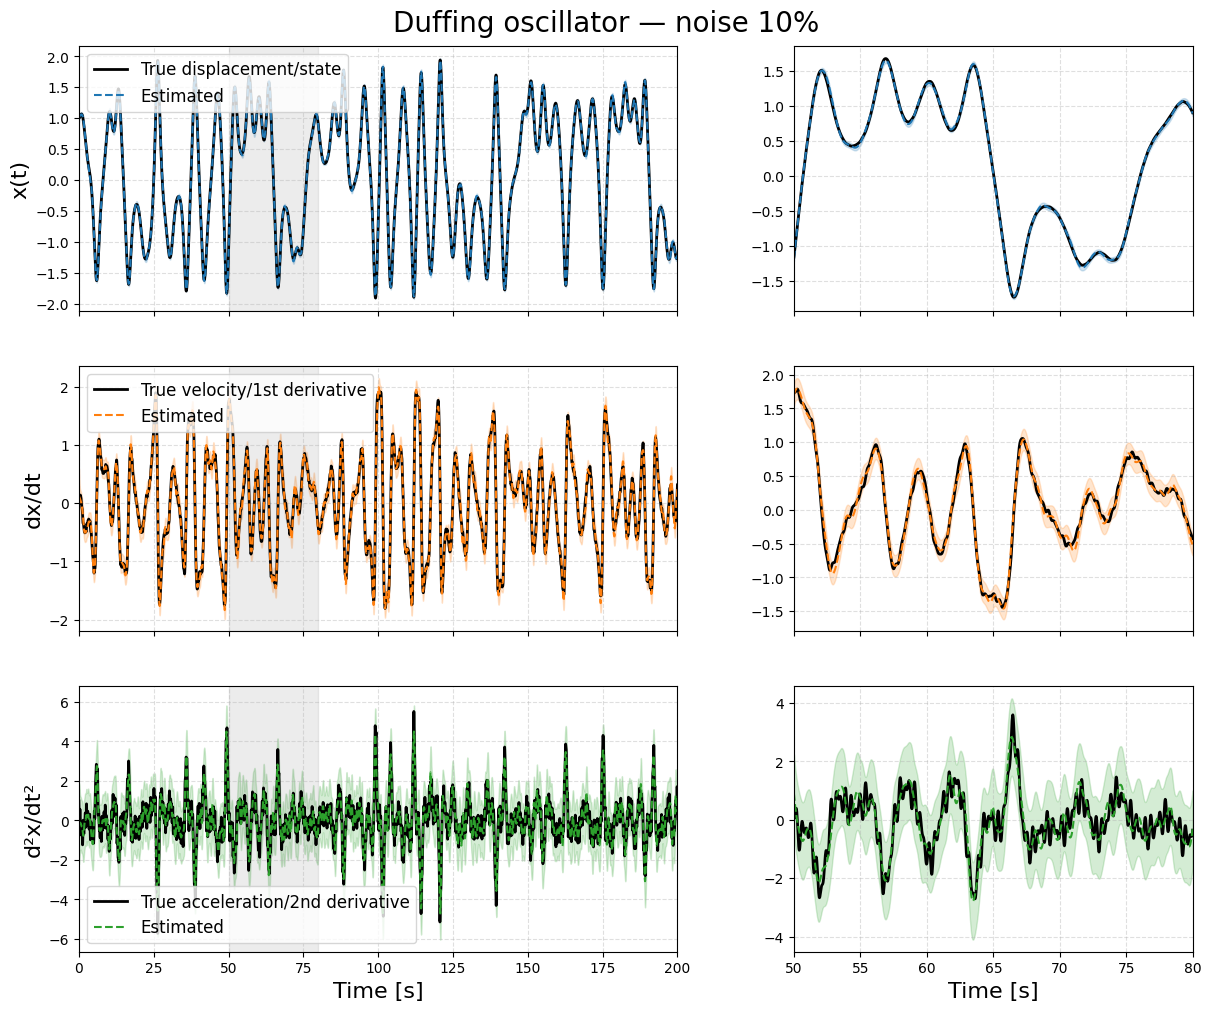

In [5]:
R_opt = sigma2_n * np.eye(1)

# Build state-space matrices with optimised hyperparameters
A, Qd, Pinf, D0, D1, D2 = Matern52(l_f, sig_f, dt)
H = [D0, D1, D2][observed_derivative]  # output matrix matching the observed derivative

# --- Kalman filter (forward pass) ---
zf, Pf = KF.kf_full_estimation(A, H, Qd, R_opt, meas_noisy.reshape(1, -1),
                                z0=np.zeros(3), P0=Pinf, return_nll=False)

# --- RTS smoother (backward pass) ---
zs, Ps = KF.rtss_full_estimation(A, zf, Pf, Qd)

# --- Extract estimates and marginal variances ---
displacement          = np.zeros(n_steps)
displacement_variance = np.zeros(n_steps)
velocity              = np.zeros(n_steps)
velocity_variance     = np.zeros(n_steps)
acceleration          = np.zeros(n_steps)
acceleration_variance = np.zeros(n_steps)

for k in range(n_steps):
    displacement[k]          = (D0 @ zs[:, k]).item()
    displacement_variance[k] = (D0 @ Ps[:, :, k] @ D0.T).item()
    velocity[k]              = (D1 @ zs[:, k]).item()
    velocity_variance[k]     = (D1 @ Ps[:, :, k] @ D1.T).item()
    acceleration[k]          = (D2 @ zs[:, k]).item()
    acceleration_variance[k] = (D2 @ Ps[:, :, k] @ D2.T).item()

# --- Plot ---
fig, axs, axs_zoom = plot_states_with_zoom(
    t, states, derivatives,
    displacement, velocity, acceleration,
    displacement_variance, velocity_variance, acceleration_variance,
    t_full_min=0.0, t_full_max=200,
    t_zoom_min=50,  t_zoom_max=80,
    fontsize_axes=16, fontsize_legends=12,
    save_path=None, figsize=(12, 10)
)
fig.set_constrained_layout(True)
fig.suptitle(f"Duffing oscillator — noise {noise_level*100:.0f}%", fontsize=20)
plt.show()

## 5. Comparison with Other Differentiation Methods

The cell below compares the GP approach against three classical methods:
- **Savitzky–Golay** smoothing + analytical differentiation
- **Tikhonov-regularised** differentiation
- **Butterworth low-pass + FFT** differentiation

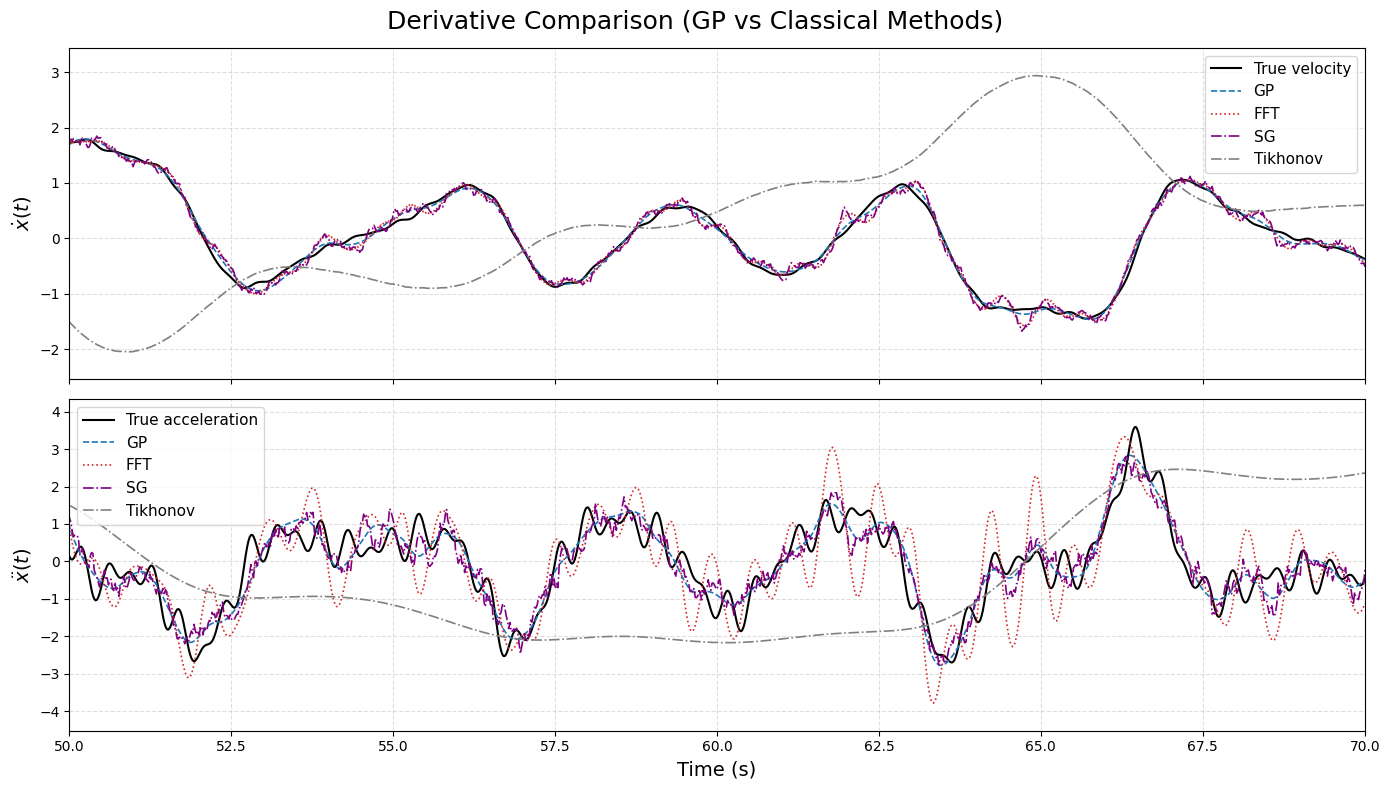

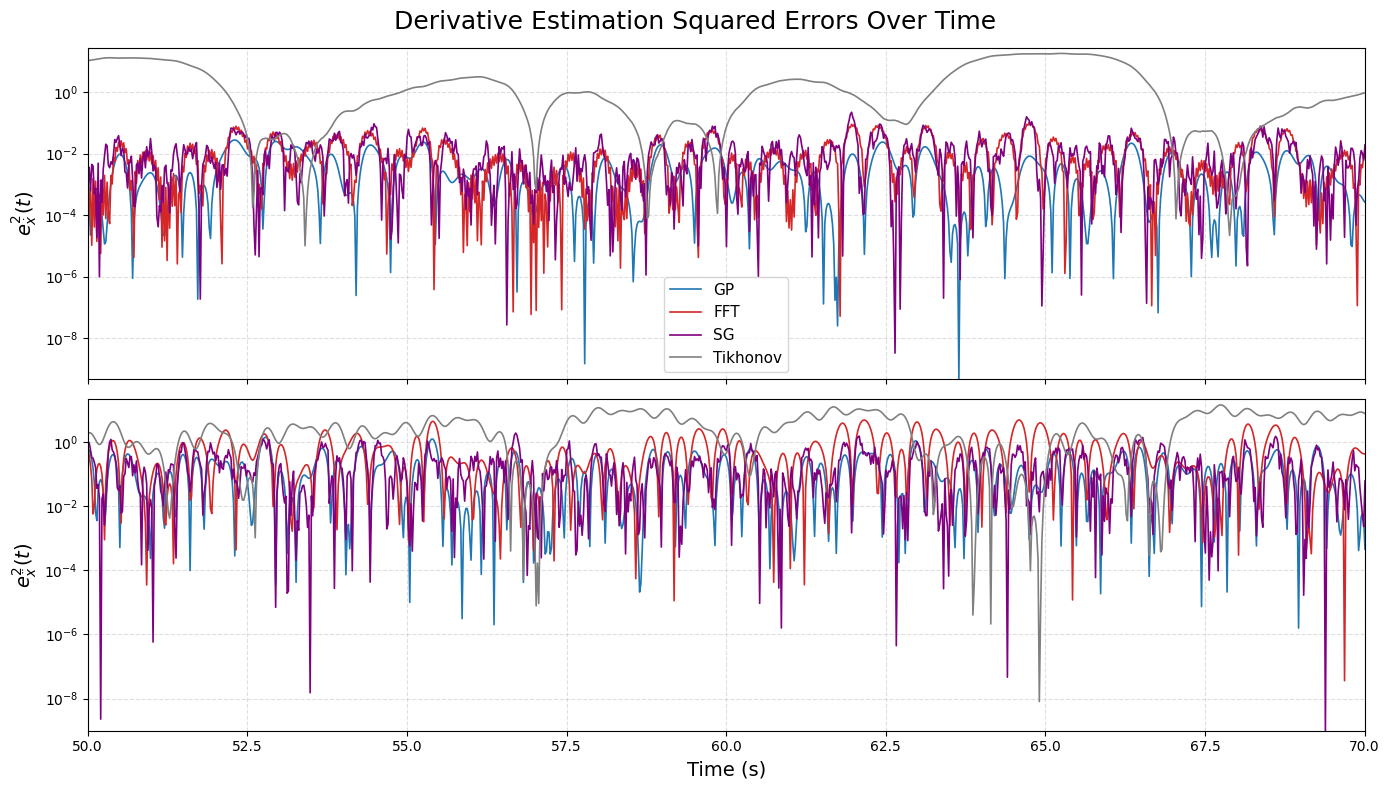

In [7]:
from plotting_functions import plot_derivative_comparison, plot_derivative_errors
from numpy.fft import fft, ifft, fftfreq
from scipy.signal import butter, sosfiltfilt, savgol_filter

# --- Savitzky-Golay ---
def savgol_differentiation(signal, dt, window=51, poly=3):
    x_sg   = savgol_filter(signal, window_length=window, polyorder=poly)
    xd_sg  = savgol_filter(signal, window_length=window, polyorder=poly, deriv=1, delta=dt)
    xdd_sg = savgol_filter(signal, window_length=window, polyorder=poly, deriv=2, delta=dt)
    return x_sg, xd_sg, xdd_sg

x_sg, xd_sg, xdd_sg = savgol_differentiation(meas_noisy, dt)

# --- Tikhonov (dense) ---
def tikhonov_diff(y, dt, lam=1e-2):
    N = len(y)
    D = (np.eye(N) - np.eye(N, k=-1)) / dt
    I = np.eye(N)
    xprime = np.linalg.solve(D.T @ D + lam * I, D.T @ y)
    return xprime

xd_tik  = tikhonov_diff(meas_noisy, dt, lam=0.1)
xdd_tik = tikhonov_diff(xd_tik,     dt, lam=0.1)

# --- Butterworth low-pass + FFT ---
def butterworth_lowpass(signal, f_cutoff, fs, order=4):
    nyq = fs / 2
    sos = butter(order, f_cutoff / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, signal)

N      = len(t)
freqs  = fftfreq(N, d=dt)
fs     = 1 / dt
f_cutoff = 1.5
x_fd   = butterworth_lowpass(meas_noisy, f_cutoff, fs, order=4)
Z_filt = fft(x_fd)
omega  = 2j * np.pi * freqs
xd_fd  = ifft(Z_filt * omega).real
xdd_fd = ifft(Z_filt * omega**2).real

fd_data = [x_fd, xd_fd, xdd_fd]

plot_derivative_comparison(
    t, derivatives, np.vstack((displacement, velocity, acceleration)),
    fd_data, x_sg, xd_sg, xdd_sg, xd_tik, xdd_tik
)

plot_derivative_errors(
    t, derivatives, np.vstack((displacement, velocity, acceleration)),
    fd_data, x_sg, xd_sg, xdd_sg, xd_tik, xdd_tik
)